In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv(r'C:\Users\apaks\Desktop\Real Estate Project\artifacts\data\preprocessed-data\gurgaon_properties_v3.csv')

In [3]:
df.isnull().sum()

property_type             0
society                   1
sector                    0
price_in_cr               0
price_per_sqft            0
area                      0
areaWithType              0
bedRoom                   0
bathroom                  0
balcony                   0
floorNum                 15
facing                  997
agePossession             0
super_built_up_area    1599
built_up_area          1975
carpet_area            1672
servant room              0
study room                0
pooja room                0
store room                0
others                    0
furnishing_type           0
luxury_score            390
area_bedroom_ratio        0
dtype: int64

### built_up_area columns

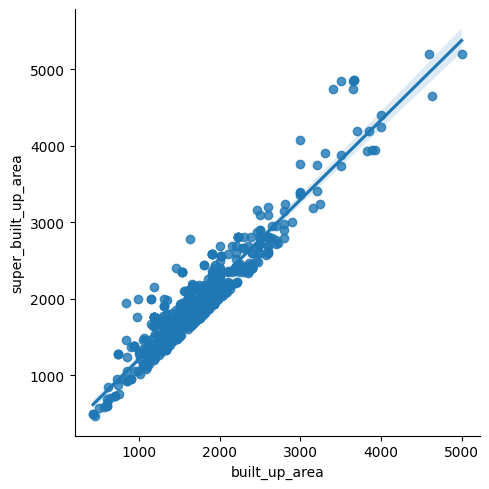

In [4]:
sns.lmplot(data = df, x = 'built_up_area', y = 'super_built_up_area')

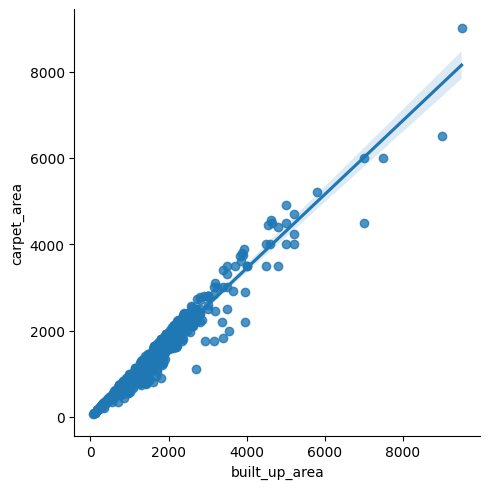

In [5]:
sns.lmplot(data = df, x = 'built_up_area', y = 'carpet_area')

- strong linear relation between built_up_area, super_built_up_area and carpet_area

In [6]:
# rows where all 3 areas are missing

df[(df['built_up_area'].isnull()) & (df['super_built_up_area'].isnull()) & (df['carpet_area'].isnull())]

,property_type,society,sector,price_in_cr,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,...,built_up_area,carpet_area,servant room,study room,pooja room,store room,others,furnishing_type,luxury_score,area_bedroom_ratio


In [7]:
# rows where all the areas are present 

all_present_df = df[~((df['built_up_area'].isnull()) | (df['super_built_up_area'].isnull()) | (df['carpet_area'].isnull()))]

In [8]:
all_present_df.shape

(532, 24)

In [9]:
# super_built_up_area vs built_up_area ration
# carpet_area vs built_up_area ratio

super_builtup_vs_builtup_ratio = (all_present_df['super_built_up_area'] / all_present_df['built_up_area']).median()
carpet_vs_builtup_ration = (all_present_df['carpet_area'] / all_present_df['built_up_area']).median()

print(super_builtup_vs_builtup_ratio, carpet_vs_builtup_ration)

1.1052289815447711 0.9071428571428571


In [10]:
# in rows where builtup area is not available and super built up and built up areas are present, we can calculate built_up_area by taking average of (super_built_up_area/1.10 + carpet_area / 0.90) --> average of prediction using the ratio of 2 other areas which the built up area is very much correlated with

temp_df = df[~(df['super_built_up_area'].isnull()) & (df['built_up_area']).isnull() & ~(df['carpet_area'].isnull())]

In [11]:
pd.set_option('display.max_columns', None)

In [12]:
temp_df.head()

,property_type,society,sector,price_in_cr,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,floorNum,facing,agePossession,super_built_up_area,built_up_area,carpet_area,servant room,study room,pooja room,store room,others,furnishing_type,luxury_score,area_bedroom_ratio
0,flat,vatika gurgaon,sector 83,1.18,6801.00,1735.04,Super Built up area 1735(161.19 sq.m.)Carpet a...,3,3,2,14.0,north,relatively new,1735.0,NaN,1500.0,0,0,0,0,0,1,16.0,578.346667
2,flat,ss the leaf,sector 85,1.10,6317.99,1741.06,Super Built up area 1741(161.74 sq.m.)Carpet a...,2,2,3+,3.0,south-east,relatively new,1741.0,NaN,1218.0,0,0,0,1,0,1,117.0,870.530000
3,flat,tarc maceo,sector 91,0.89,6338.99,1404.01,Super Built up area 1404(130.44 sq.m.)Carpet a...,2,2,3+,9.0,east,relatively new,1404.0,NaN,1200.0,0,0,0,0,1,0,9.0,702.005000
11,flat,tulip violet,sector 69,1.51,9569.01,1578.01,Super Built up area 1578(146.6 sq.m.)Carpet ar...,3,3,2,0.0,west,relatively new,1578.0,NaN,1100.0,0,0,1,0,0,2,145.0,526.003333
41,flat,bestech park view ananda,sector 81,1.10,6686.00,1645.23,Super Built up area 1645(152.83 sq.m.)Carpet a...,3,2,3+,5.0,east,relatively new,1645.0,NaN,1034.0,0,0,0,0,0,1,125.0,548.410000


In [13]:
temp_df['built_up_area'] = temp_df['built_up_area'].fillna(round(((temp_df['super_built_up_area']/super_builtup_vs_builtup_ratio) + (temp_df['carpet_area']/carpet_vs_builtup_ration)) / 2))

In [14]:
temp_df['built_up_area'].isnull().sum()

np.int64(0)

In [15]:
df.update(temp_df)

In [16]:
df.isnull().sum()

property_type             0
society                   1
sector                    0
price_in_cr               0
price_per_sqft            0
area                      0
areaWithType              0
bedRoom                   0
bathroom                  0
balcony                   0
floorNum                 15
facing                  997
agePossession             0
super_built_up_area    1599
built_up_area          1553
carpet_area            1672
servant room              0
study room                0
pooja room                0
store room                0
others                    0
furnishing_type           0
luxury_score            390
area_bedroom_ratio        0
dtype: int64

In [17]:
# rows where super built up area is present, built up is null but carpet area is null

temp_df = df[(~df['super_built_up_area'].isnull()) & (df['built_up_area'].isnull()) & (df['carpet_area'].isnull())]

In [18]:
# built_up_area = (super_built_up_area/1.10)

temp_df['built_up_area'] = round(df['super_built_up_area']/1.10)

In [19]:
df.update(temp_df)

In [20]:
df.isnull().sum()

property_type             0
society                   1
sector                    0
price_in_cr               0
price_per_sqft            0
area                      0
areaWithType              0
bedRoom                   0
bathroom                  0
balcony                   0
floorNum                 15
facing                  997
agePossession             0
super_built_up_area    1599
built_up_area           656
carpet_area            1672
servant room              0
study room                0
pooja room                0
store room                0
others                    0
furnishing_type           0
luxury_score            390
area_bedroom_ratio        0
dtype: int64

In [21]:
# rows where super_built_up area is null but carpet area is present and built_up area is also not present

temp_df = df[(df['super_built_up_area'].isnull()) & (df['built_up_area'].isnull()) & (~df['carpet_area'].isnull())]

In [22]:
temp_df.shape

(656, 24)

In [26]:
temp_df.head()

,property_type,society,sector,price_in_cr,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,floorNum,facing,agePossession,super_built_up_area,built_up_area,carpet_area,servant room,study room,pooja room,store room,others,furnishing_type,luxury_score,area_bedroom_ratio
4,flat,rwa,sector 7,0.48,6000.00,800.00,Carpet area: 800 (74.32 sq.m.),3,2,1,1.0,north-east,new,NaN,889.0,800.0,0,0,0,0,0,1,12.0,266.666667
10,flat,signature global city 92,sector 92,0.99,6621.98,1495.02,Carpet area: 1495 (138.89 sq.m.),3,2,3,1.0,east,new,NaN,1661.0,1495.0,0,0,0,0,1,1,18.0,498.340000
28,house,independent,sector 13,2.25,6943.99,3240.21,Carpet area: 360 (301.01 sq.m.),10,10,2,1.0,East,undefined,NaN,400.0,360.0,0,0,0,0,0,1,NaN,324.021000
37,flat,umang winter hills,sector 77,1.00,7500.02,1333.33,Carpet area: 1340 (124.49 sq.m.),2,2,2,3.0,NaN,new,NaN,1489.0,1340.0,0,0,0,0,0,1,53.0,666.665000
43,flat,apartment,sector 92,0.75,4687.00,1600.17,Carpet area: 1600 (148.64 sq.m.),3,4,3,2.0,east,relatively old,NaN,1778.0,1600.0,0,1,0,0,0,1,89.0,533.390000


In [23]:
# builtup_area = carpet_area/0.9

temp_df['built_up_area'] = temp_df['built_up_area'].fillna((df['carpet_area']/0.9).round())

In [24]:
df.update(temp_df)

In [27]:
df.isnull().sum()

property_type             0
society                   1
sector                    0
price_in_cr               0
price_per_sqft            0
area                      0
areaWithType              0
bedRoom                   0
bathroom                  0
balcony                   0
floorNum                 15
facing                  997
agePossession             0
super_built_up_area    1599
built_up_area             0
carpet_area            1672
servant room              0
study room                0
pooja room                0
store room                0
others                    0
furnishing_type           0
luxury_score            390
area_bedroom_ratio        0
dtype: int64

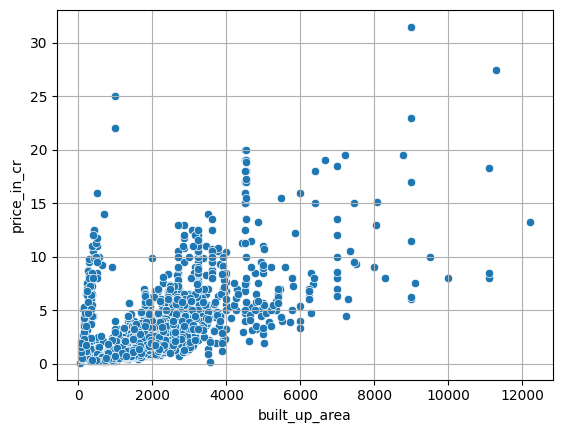

In [ ]:
# scatter plot to check any anomaly with price and builtup area relation

sns.scatterplot(x = df['built_up_area'], y = df['price_in_cr'])
plt.grid()

- scatter plot indicate some of the properties with very small builtup area but unusually high price

In [57]:
# properties with less built_up_area < 2000 and price > 2.5cr

anomaly_df = df[(df['built_up_area'] < 2000) & (df['price_in_cr'] > 2.5)]

In [58]:
anomaly_df[['price_in_cr', 'area', 'built_up_area']].sample(10)

,price_in_cr,area,built_up_area
2685,2.64,2251.60,1750.75
422,2.55,1650.06,1463.00
700,2.68,1556.96,1557.00
745,9.50,4914.00,546.00
798,2.79,1860.00,1558.00
631,5.25,1934.98,1935.00
1308,6.25,1800.01,1800.00
1010,3.15,2152.82,222.00
2250,6.40,3150.07,349.00
2496,2.90,2003.04,1821.00


In [63]:
# replacing builtup area with area in these rows

anomaly_df['built_up_area'] = anomaly_df['area']

In [64]:
df.update(anomaly_df)

<Axes: xlabel='built_up_area', ylabel='price_in_cr'>

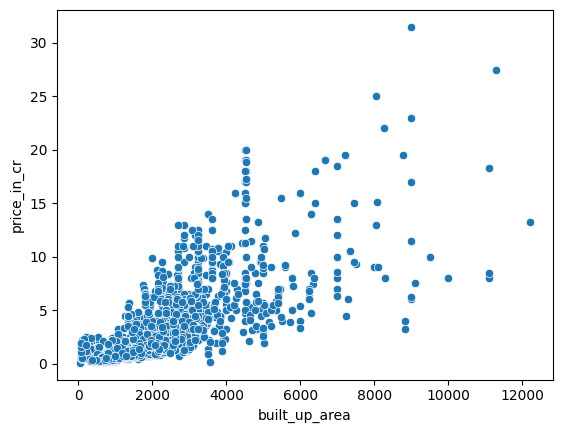

In [65]:
# plotting scatter plot again to if the anomalies have been removed

sns.scatterplot(x = df['built_up_area'], y= df['price_in_cr'])

In [67]:
df.isnull().sum()

property_type             0
society                   1
sector                    0
price_in_cr               0
price_per_sqft            0
area                      0
areaWithType              0
bedRoom                   0
bathroom                  0
balcony                   0
floorNum                 15
facing                  997
agePossession             0
super_built_up_area    1599
built_up_area             0
carpet_area            1672
servant room              0
study room                0
pooja room                0
store room                0
others                    0
furnishing_type           0
luxury_score            390
area_bedroom_ratio        0
dtype: int64